#Mount the Google drive 

This is done for accessing the drive files as we have our cropped images stored in the drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


Go to the directory containing the files and csv files required for training

In [ ]:
%cd /content/drive/MyDrive/Classification-dental

/content/drive/.shortcut-targets-by-id/1eoEU8dzgK28n1fZSFE_Q1d0pwYF7YtwC/Classification-dental


#Import the required libraries

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import os
import keras
from keras.models import Model
from keras.layers import Conv2D, MaxPooling2D, Dense, Input, Activation, Dropout, GlobalAveragePooling2D, \
    BatchNormalization, concatenate, AveragePooling2D
from keras.optimizers import Adam
from keras.utils import np_utils
from sklearn.model_selection import train_test_split
import sys
import matplotlib
from sklearn import metrics

Read the csv file which has all the images names and its labels as columns in the form of pandas dataframe

In [ ]:
df=pd.read_csv("train.csv")
df.head()

,Unnamed: 0,id,Label
0,0,H 01711030003-opg_1.jpg,H
1,1,H 01711030003-opg_12.jpg,H
2,2,H 01711030003-opg_13.jpg,H
3,3,H 01711030003-opg_14.jpg,H
4,4,H 01711030003-opg_15.jpg,H


Remove the unwanted column in the above displayed dataframe

In [ ]:
df.drop(['Unnamed: 0'],axis=1,inplace=True)

Replace the label names with integer values

In [ ]:
df["Label"].replace({"H": 0, "T": 1,"U":2}, inplace=True)

Display the first 5 rows of the dataframe

In [ ]:
df.head()

,id,Label
0,H 01711030003-opg_1.jpg,0
1,H 01711030003-opg_12.jpg,0
2,H 01711030003-opg_13.jpg,0
3,H 01711030003-opg_14.jpg,0
4,H 01711030003-opg_15.jpg,0


Display the number of samples and the labels in integer form

In [ ]:
print("Number of samples: ",len(df))
print("Number of Labels: ",np.unique(df.Label))

Number of samples:  7211
Number of Labels:  [0 1 2]


Plot to show the distribution of the labels

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


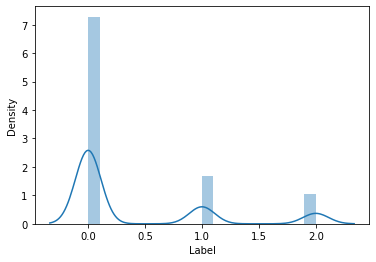

In [ ]:
sns.distplot(df.Label)

Convert the dataset to the required format for the model to train

In [ ]:
from PIL import Image 
from skimage.transform import resize
train=pd.read_csv("/content/drive/MyDrive/ALL_NEW/train.csv")
train.drop(['Unnamed: 0'],axis=1,inplace=True)
train["Label"].replace({"H": 0, "T": 1,"U":2}, inplace=True)
train_images=[]
path="/content/drive/MyDrive/ALL_NEW/train/"
for i in train.id:
    image=plt.imread(path+i)
    train_images.append(image)

Display the size of X and y which are the images in numpy form and their respective labels

In [ ]:
train_images=np.asarray(train_images)
X=train_images
y=train.Label
print("Labels: ",y.shape)
print("images: ",X.shape)

Labels:  (7211,)
images:  (7211, 224, 224, 3)


#Show a sample from the dataframe

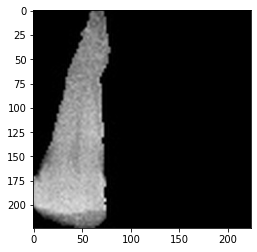

In [ ]:
plt.imshow(X[2])

#Model Definition for DenseNet-121

In [ ]:
def conv_layer(conv_x, filters):
    conv_x = BatchNormalization()(conv_x)
    conv_x = Activation('relu')(conv_x)
    conv_x = Conv2D(filters, (3, 3), kernel_initializer='he_uniform', padding='same', use_bias=False)(conv_x)
    conv_x = Dropout(0.2)(conv_x)

    return conv_x


def dense_block(block_x, filters, growth_rate, layers_in_block):
    for i in range(layers_in_block):
        each_layer = conv_layer(block_x, growth_rate)
        block_x = concatenate([block_x, each_layer], axis=-1)
        filters += growth_rate

    return block_x, filters


def transition_block(trans_x, tran_filters):
    trans_x = BatchNormalization()(trans_x)
    trans_x = Activation('relu')(trans_x)
    trans_x = Conv2D(tran_filters, (1, 1), kernel_initializer='he_uniform', padding='same', use_bias=False)(trans_x)
    trans_x = AveragePooling2D((2, 2), strides=(2, 2))(trans_x)

    return trans_x, tran_filters


def dense_net(filters, growth_rate, classes, dense_block_size, layers_in_block):
    input_img = Input(shape=(224, 224, 3))
    x = Conv2D(24, (3, 3), kernel_initializer='he_uniform', padding='same', use_bias=False)(input_img)

    dense_x = BatchNormalization()(x)
    dense_x = Activation('relu')(x)

    dense_x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(dense_x)
    for block in range(dense_block_size - 1):
        dense_x, filters = dense_block(dense_x, filters, growth_rate, layers_in_block)
        dense_x, filters = transition_block(dense_x, filters)

    dense_x, filters = dense_block(dense_x, filters, growth_rate, layers_in_block)
    dense_x = BatchNormalization()(dense_x)
    dense_x = Activation('relu')(dense_x)
    dense_x = GlobalAveragePooling2D()(dense_x)

    output = Dense(classes, activation='softmax')(dense_x)

    return Model(input_img, output)

#Split into train and test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
Cat_test_y = np_utils.to_categorical(y_test)
y_train=np_utils.to_categorical(y_train)

print("X_train shape : ",X_train.shape)
print("y_train shape : ",y_train.shape)
print("X_test shape : ",X_test.shape)
print("y_test shape : ",y_test.shape)

X_train shape :  (4831, 224, 224, 3)
y_train shape :  (4831, 3)
X_test shape :  (2380, 224, 224, 3)
y_test shape :  (2380,)


Function definiton for handling class imbalance

In [ ]:
def getWeights(df, classes):
  classWeight = {}

  for idx, i in enumerate(classes):
    classWeight[idx] = (1 - len(train[train['Label'] == idx]) / len(train)) / 2

  return classWeight

#Training starts here

In [ ]:
dense_block_size = 3
layers_in_block = 4

growth_rate = 12
classes = 3
classes_new = ['H','T','U']
model = dense_net(growth_rate * 2, growth_rate, classes, dense_block_size, layers_in_block)
model.summary()
classWeight = {}
classWeight = getWeights(train, classes_new)

# training
batch_size = 32
epochs = 15
optimizer = Adam(lr=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
model.compile(optimizer = optimizer, loss = 'categorical_crossentropy', metrics=['accuracy',keras.metrics.Precision(),keras.metrics.AUC(),keras.metrics.Recall()])


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 224, 224, 24) 648         input_1[0][0]                    
__________________________________________________________________________________________________
activation (Activation)         (None, 224, 224, 24) 0           conv2d[0][0]                     
__________________________________________________________________________________________________
max_pooling2d (MaxPooling2D)    (None, 112, 112, 24) 0           activation[0][0]                 
______________________________________________________________________________________________

In [ ]:
history=model.fit(X_train,y_train, epochs=epochs, batch_size=batch_size, shuffle=True,validation_data=(X_test, Cat_test_y),class_weight=classWeight)

Epoch 1/15
151/151 [==============================] - ETA: 0s - loss: 0.2110 - accuracy: 0.6938 - precision: 0.7757 - auc: 0.8277 - recall: 0.2422

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py", line 2882, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-17-8b6b04f0cda0>", line 1, in <module>
    history=model.fit(X_train,y_train, epochs=epochs, batch_size=batch_size, shuffle=True,validation_data=(X_test, Cat_test_y),class_weight=classWeight)
  File "/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/engine/training.py", line 1117, in fit
    self._fit_frame = tf_inspect.currentframe()
  File "/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/utils/tf_inspect.py", line 95, in currentframe
    return _inspect.stack()[1][0]
  File "/usr/lib/python3.7/inspect.py", line 1513, in stack
    return getouterframes(sys._getframe(1), context)
  File "/usr/lib/python3.7/inspect.py", line 1490, in getouterframes
    frameinfo = (frame,) + getframeinfo(frame, context)
  File "/usr/lib/python3.7/inspect.py", lin

FileNotFoundError: ignored

#Saving the model

In [ ]:
model.save('/content/drive/MyDrive/ALL_NEW/BalancedWeight1-epoch15-batch32.h5')

#Generating the loss and accuracy plots for traning and validation

Generating plots...


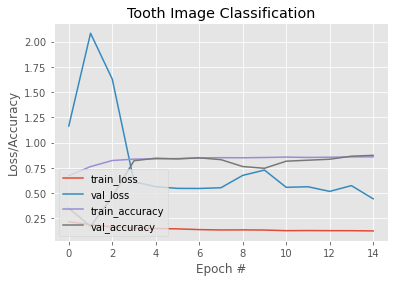

In [ ]:
print("Generating plots...")
sys.stdout.flush()
matplotlib.use("Agg")
matplotlib.pyplot.style.use("ggplot")
matplotlib.pyplot.figure()
N = epochs 
matplotlib.pyplot.plot(np.arange(0, N), history.history["loss"], label="train_loss")
matplotlib.pyplot.plot(np.arange(0, N), history.history["val_loss"], label="val_loss")
matplotlib.pyplot.plot(np.arange(0, N), history.history["accuracy"], label="train_accuracy")
matplotlib.pyplot.plot(np.arange(0, N), history.history["val_accuracy"], label="val_accuracy")
matplotlib.pyplot.title("Tooth Image Classification")
matplotlib.pyplot.xlabel("Epoch #")
matplotlib.pyplot.ylabel("Loss/Accuracy")
matplotlib.pyplot.legend(loc="lower left")
matplotlib.pyplot.savefig("plot.png")

#Generating the classification report

In [ ]:
label_pred = model.predict(X_test)

pred = []
for i in range(len(label_pred)):
    pred.append(np.argmax(label_pred[i]))

Y_test = np.argmax(Cat_test_y, axis=1) # Convert one-hot to index

print(metrics.classification_report(Y_test, pred))



              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1757
           1       0.92      0.75      0.83       390
           2       0.69      0.27      0.39       233

    accuracy                           0.87      2380
   macro avg       0.83      0.67      0.71      2380
weighted avg       0.86      0.87      0.86      2380



#Display validation accuracy

In [ ]:
label_pred = model.predict(X_test)

pred = []
for i in range(len(label_pred)):
    pred.append(np.argmax(label_pred[i]))

Y_test = np.argmax(Cat_test_y, axis=1) # Convert one-hot to index

print(metrics.accuracy_score(Y_test, pred))



0.873109243697479
